# Job Hunting Agent using ReWOO

### Import Modules

In [111]:
from dotenv import load_dotenv
import os
import docx
import pdfplumber
import subprocess
from openai import OpenAI

### Add OPENAI_API_KEY to Environment Variable

In [112]:
# Please make sure to create a .env file in the root directory of the project and add your OpenAI API key as follows:
# OPENAI_API_KEY="<your_openai_api_key_here>"

# Please make sure to create a .env file in the root directory of the project and add your LangSmith API key as follows:
# LANGCHAIN_API_KEY="<your_langsmith_api_key_here>"
# LANGSMITH_API_KEY="<your_langsmith_api_key_here>"
# LANGSMITH_TRACING=<true_or_false>
# LANGCHAIN_TRACING_V2=<true_or_false>
# LANGSMITH_ENDPOINT="<your_langsmith_endpoint_here>" (if using a custom endpoint, otherwise it defaults to https://api.smith.langchain.com)
# LANGSMITH_PROJECT="<your_agent_name_here>"

load_dotenv()


True

## Building ReWOO Agent

### Build Planner Node

In [113]:
from typing import List, TypedDict, Dict, Any
import re
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langsmith import traceable

In [114]:
class ReWOO(TypedDict):
    task:str
    plan_string: str
    steps: List
    results: dict
    result: str
    

In [115]:
llm_model = ChatOpenAI(
                            model = "gpt-5.4-mini"
                        )

In [116]:
planner_prompt = """For the following task, make plans that can solve the problem step by step. For each plan, indicate
which external tool together with tool input to retrieve evidence. You can store the evidence into a
variable #E that can be called by later tools. (Plan, #E1, Plan, #E2, Plan, ...) Use the following format:
Plan: Explain the plan.
#E1 = TOOL[tool-input] 

Plan: Explain the plan for the next step
#E2 = TOOL[tool-input]


Allowed TOOLs:  
1) LLM[input]    – Let the language model reason  
2) CV[input]     – The tool extract_cv_text, input = local path  
3) JobPost[input]– The tool job_posting_scraper, input = a job-url  

Do not invent any other tool names.  
Begin!

Task: {task}
"""

In [117]:
task = """
look into my cv in "data/cv_sample.pdf" can you evaluate it 
and how would it perform on this posting: https://www.linkedin.com/jobs/view/4402161329
"""

In [118]:
result = llm_model.invoke(planner_prompt.format(task=task))

result.pretty_print()

================================== Ai Message ==================================

Plan: First, extract the text from your CV so I can understand your background, skills, experience, education, and formatting. This will be the evidence base for the evaluation.
#E1 = CV[data/cv_sample.pdf]

Plan: Next, retrieve the job posting details from the LinkedIn URL to identify the role requirements, responsibilities, qualifications, and keywords needed for comparison.
#E2 = JobPost[https://www.linkedin.com/jobs/view/4402161329]

Plan: Then, compare the CV evidence against the job posting evidence to evaluate fit, identify strengths, gaps, keyword alignment, and likely ATS performance. I’ll use the extracted evidence from #E1 and #E2 to produce a concise assessment and recommendations.
#E3 = LLM[Compare #E1 with #E2 and evaluate how well the CV matches the job posting. Include: overall fit, matched skills, missing qualifications, ATS/keyword alignment, and specific improvements to better target th

In [119]:
# Define Regex to parse the plan, tool, and tool input from the LLM output
plan_regex = r"Plan:\s*(.+?)\s*(#E\d+)\s*=\s*(\w+)\[(.+?)\]"

In [120]:
matches = re.findall(plan_regex, result.content, flags=re.S)

for plan, evidence_var, tool_name, tool_input in matches:
    print(f"{evidence_var} = {tool_name}[{tool_input}]")
    print(f"  Plan: {plan}")

#E1 = CV[data/cv_sample.pdf]
  Plan: First, extract the text from your CV so I can understand your background, skills, experience, education, and formatting. This will be the evidence base for the evaluation.
#E2 = JobPost[https://www.linkedin.com/jobs/view/4402161329]
  Plan: Next, retrieve the job posting details from the LinkedIn URL to identify the role requirements, responsibilities, qualifications, and keywords needed for comparison.
#E3 = LLM[Compare #E1 with #E2 and evaluate how well the CV matches the job posting. Include: overall fit, matched skills, missing qualifications, ATS/keyword alignment, and specific improvements to better target this role.]
  Plan: Then, compare the CV evidence against the job posting evidence to evaluate fit, identify strengths, gaps, keyword alignment, and likely ATS performance. I’ll use the extracted evidence from #E1 and #E2 to produce a concise assessment and recommendations.


In [121]:
@traceable(name = "Planner Node")
def planner_node(state: ReWOO):
    task = state['task']
    raw_plan =  llm_model.invoke(planner_prompt.format(task=task)).content
    steps = re.findall(plan_regex, raw_plan, flags=re.S)
    
    return ReWOO(plan_string=raw_plan, steps=steps)

### Integrate CV Reader Tool and Web Search Tool into the Agent

In [122]:
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode

In [123]:
@tool
def extract_cv_text(file_path: str) -> str:
    """
    Extract text content from a CV/resume file.
    
    Supports .docx, .pdf, and .doc formats. For .doc files, 
    LibreOffice (soffice) is used to convert to .docx first.
    
    Args:
        file_path: Path to the CV/resume file (.docx, .pdf, or .doc).
    
    Returns:
        str: Extracted text content from the file, or an error message if reading fails.
    """
    
    ext = os.path.splitext(file_path)[-1].lower()
    
    if '.docx' in ext:
        
        try:
            
            doc = docx.Document(file_path)
            
            text = [para.text for para in doc.paragraphs]
            
            return '\n'.join(text)
        
        except Exception as e:
            
            return f"Error reading .doc file: {e}"
        
    elif '.pdf' in ext:
        
        try:
            text = []
            
            with pdfplumber.open(file_path) as pdf:
                
                for page in pdf.pages:
                    page_text = page.extract_text()
                    
                    if page_text:
                        text.append(page_text)
                    
            
            return '/n'.join(text)
        
        except Exception as e:
            
            return f"Error reading .pdf file: {e}"
    
    elif '.doc' in ext:
        
        
        try:
            
            temp_docx = file_path + '.temp.docx'
            
            subprocess.run(['soffice', '--headless', '--convert-to', 'docx', '--outdir', os.path.dirname(file_path), file_path], check=True)
            
            doc = docx.Document(temp_docx)
            
            text = [para.text for para in text.paragraphs]
            
            return '\n'.join(text)
        
        except Exception as e:
            
            return f"Error reading .doc file: {e}"
            
        
    else:
        
        return "Unsupported file format. Please upload a .doc, .docx, or .pdf file."

In [124]:
@tool
def job_posting_scraper(job_link: str) -> str:
    """
    Scrape job posting details from a given URL.
    
    Args:
        job_link: URL of the job posting to scrape.
    
    Returns:
        str: A structured summary of the job posting details, or an error message if scraping fails.
    """
    
    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
    
    completion = client.chat.completions.create(
                            model = "gpt-4o-search-preview",
                            web_search_options = {
                                "search_context_size": "medium"
                            },
                            messages = [
                                {
                                    "role": "system",
                                    "content": """
                                    You are a helpful tool that visits the following job posting and carefully reads its content.
                                    Visit the provided link and summarize the key details in a clear and concise format, including:
                                    - Job Title
                                    - Company Name
                                    - Location
                                    - Job Description
                                    - Employment Type (e.g., Full-time, Part-time, Contract)
                                    - Required Qualifications
                                    - Preferred Qualifications
                                    - Application Instructions
                                    - Salary Range (if listed)
                                    - Primary Responsibilities
                                    - Benefits (if listed)
                                    - Posting Date (if available)
                                    - Any other relevant information that would help a job seeker understand the role and how to apply
                                    
                                    Format:
                                    - Respond with a clear and structured bullet point list
                                    - Use exact factual information from the posting, no rewording beyond make it concise.
                                    - If the posting is missing, inaccessible or contains no job details, respond with "Job posting unavailable or contains no job details."
                                    
                                    Do's:
                                    - Do visit the provided link and read the job posting carefully.
                                    - Ensure all extracted details are accurate and directly taken from the posting.
                                    - Keep descriptions concise while retaining all critical information, short, professional and easy to scan.
                                    - Use consistent formatting for all fields (e.g. "Job Title: ...")
                                    
                                    Dont's:
                                    - Do not include any information that is not explicitly stated in the job posting.
                                    - Do not make assumptions or add interpretations beyond what is provided in the posting.
                                    - Do not include filler language, speculation or personal opinions.
                                    - Do not rewrite or interpret details-only report factual information from the posting. 
                                    """
                                },
                                {
                                    "role": "user",
                                    "content": f"Visit this job posting link and extract details: \n {job_link}"
                                }
                            ]
                        )
    
    return completion.choices[0].message.content

In [125]:
tools = [extract_cv_text, job_posting_scraper]

### Build Executor Node

In [126]:
# Helper function to check where we are now on

def _current_index(state: ReWOO):
    
    done = len(state.get("results", {}))
    total = len(state['steps'])
    
    return None if done >= total else done

In [127]:
@traceable(name = "Executor Node")
def executor_node(state: ReWOO):
    
    current_index = _current_index(state)
    
    if current_index is None:
        return {}
    
    plan_text, step_name, tool_name, tool_input = state['steps'][current_index]
    
    for k,v in state.get("results", {}).items():
        if tool_name == "LLM" and k in tool_input:
            tool_input = tool_input.replace(k, v)
        
    
    if tool_name == "LLM":
        out = llm_model.invoke(tool_input).content
    elif tool_name == "CV":
        out = extract_cv_text.invoke(tool_input)
    elif tool_name == "JobPost":
        out = job_posting_scraper.invoke(tool_input)
    else:
        raise ValueError(f"Unknown tool: {tool_name}")
    
    
    
    results = dict(state.get("results", {}))
    results[step_name] = str(out)
    
    return ReWOO(results= results)

### Build Solver Node

In [128]:
solver_prompt = """
Solve the following task or problem. To solve the problem, we have made step-by-step Plan and 
retrieved corresponding Evidence to each Plan. Use them with caution since long evidence might 
contain irrelevant information.

{plan_block}

Now solve the question or task according to provided Evidence above. Respond with the answer
directly with no extra words.

Task: {task}
Response:

"""

In [129]:
@traceable(name = "Solver Node")
def solver_node(state: ReWOO):
    
    lines = []
    
    for plan_text, step_name, tool_name, tool_input in state['steps']:
        evidence = state['results'][step_name]
        lines.append(f"Plan: {plan_text}\nEvidence: {evidence}\n")
        
    
    prompt = solver_prompt.format(plan_block='\n'.join(lines), task=state['task'])
    
    answer = llm_model.invoke(prompt).content.strip()
    
    return ReWOO(result=answer)

### Build Router Function to determine next step after each Execution

In [130]:
from typing import Literal

In [131]:
def router(state: ReWOO) -> Literal["solver", "executor"]:
    
    return "solver" if _current_index(state) is None else "executor"

### Building Graph

In [132]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langgraph.graph import START, END, StateGraph
from IPython.display import Image, display

In [133]:
agent_graph = StateGraph(ReWOO)

In [134]:
agent_graph.add_node("planner", planner_node)
agent_graph.add_node("executor", executor_node)
agent_graph.add_node("solver", solver_node)

In [135]:
agent_graph.add_edge(START, "planner")
agent_graph.add_edge("planner", "executor")
agent_graph.add_conditional_edges(source = "executor", path = router)
agent_graph.add_edge("solver", END)

In [136]:
messages = [
    HumanMessage(content="""
                 
                 Can you take a look at my CV at the location "data/cv_sample.pdf" and tell me how well it matches the requirements for the following jobs: 
                 
                 https://www.linkedin.com/jobs/view/4402161329
                 https://www.linkedin.com/jobs/view/4409462037
                 https://www.linkedin.com/jobs/view/4343051642
                 
                 
                 Tell me which one is the most suitable for my experience and skills, and what improvements I can make to my CV to increase my chances of getting an interview for that job.
                 
                 """)
]

In [137]:
from langgraph.checkpoint.memory import InMemorySaver

In [138]:
memory = InMemorySaver()

In [139]:
agent_graph_runnable_with_memory = agent_graph.compile(checkpointer = memory)


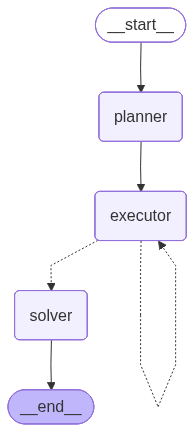

In [140]:
agent_graph_runnable_with_memory

In [141]:
config = {"configurable": {
    "thread_id": "job_hunting_thread_1"
}}

In [142]:
request = ReWOO(task = messages[0].content,
                 plan_string = "",
                 steps = [],
                 results = {},
                 result=""
                )

request

{'task': '\n\n                 Can you take a look at my CV at the location "data/cv_sample.pdf" and tell me how well it matches the requirements for the following jobs: \n\n                 https://www.linkedin.com/jobs/view/4402161329\n                 https://www.linkedin.com/jobs/view/4409462037\n                 https://www.linkedin.com/jobs/view/4343051642\n\n\n                 Tell me which one is the most suitable for my experience and skills, and what improvements I can make to my CV to increase my chances of getting an interview for that job.\n\n                 ',
 'plan_string': '',
 'steps': [],
 'results': {},
 'result': ''}

In [143]:
for event in agent_graph_runnable_with_memory.stream(request, config = config):
    print(event)
    print("---")
    
print(f"\n\n FINAL ANSWER : \n\n {event['solver']['result']}")

{'planner': {'plan_string': 'Plan: First extract the full text of the CV from the PDF so we can identify the candidate’s skills, experience, education, and keywords.\n#E1 = CV[data/cv_sample.pdf]\n\nPlan: Next, retrieve the full job descriptions and requirements for all three LinkedIn postings so we can compare them against the CV evidence.\n#E2 = JobPost[https://www.linkedin.com/jobs/view/4402161329]\n#E3 = JobPost[https://www.linkedin.com/jobs/view/4409462037]\n#E4 = JobPost[https://www.linkedin.com/jobs/view/4343051642]\n\nPlan: Then analyze the CV evidence against each job posting to determine fit, highlight matching qualifications, gaps, and any missing keywords or experience.\n#E5 = LLM[Compare #E1 with #E2, #E3, and #E4; assess match level for each role and identify strongest alignment]\n\nPlan: Finally, use the comparison to rank the jobs by suitability and generate specific CV improvement recommendations tailored to the best-matching role.\n#E6 = LLM[Based on #E5, recommend wh

In [149]:
final_result = agent_graph_runnable_with_memory.invoke(request, config = config)

In [150]:
final_result

{'task': '\n\n                 Can you take a look at my CV at the location "data/cv_sample.pdf" and tell me how well it matches the requirements for the following jobs: \n\n                 https://www.linkedin.com/jobs/view/4402161329\n                 https://www.linkedin.com/jobs/view/4409462037\n                 https://www.linkedin.com/jobs/view/4343051642\n\n\n                 Tell me which one is the most suitable for my experience and skills, and what improvements I can make to my CV to increase my chances of getting an interview for that job.\n\n                 ',
 'plan_string': 'Plan: First extract the text from the CV so we can understand your experience, skills, education, and keywords.  \n#E1 = CV[data/cv_sample.pdf]\n\nPlan: Next, retrieve the full job descriptions and requirements for each LinkedIn job link so we can compare them against your CV.  \n#E2 = JobPost[https://www.linkedin.com/jobs/view/4402161329]  \n\nPlan: Retrieve the second job posting for comparison. 

In [152]:
print(final_result['result'])

Your CV matches the three roles as follows:

1. Tesla Energy EMEA – Sr. Digital Analyst  
   - Best match  
   - Fit: Medium to Strong  
   - Why: Your background in psychology, statistics, research, data acquisition, and analysis transfers well to analytics, experimentation, and cross-functional work.  
   - Main gaps: no explicit web analytics, SQL, GA4, GTM, BigQuery, BI tools, paid media, or CRM integration experience.

2. Amazon Advertising – Analytics and Insight Professional  
   - Second best match  
   - Fit: Medium  
   - Why: Your analytical background and experience presenting findings can translate to insight generation and stakeholder communication.  
   - Main gaps: no direct marketing analytics, advertiser performance, executive-facing insights, or Amazon-specific metrics experience.

3. Deloitte – Senior Consultant Data Analytics & Business Insights  
   - Lowest confidence / low to medium fit  
   - Why: Job details are unavailable, but the title suggests consulting a